In [1]:
# CELL 1: Imports and Load Collected Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Loading collected data...\n")

# Load fundamentals
fundamentals = pd.read_csv("data/processed/fundamentals.csv")
print(f"Fundamentals loaded: {fundamentals.shape[0]} stocks, {fundamentals.shape[1]} columns")

# Load price data (multi-ticker format)
price_data = pd.read_pickle("data/raw/historical_prices_multi.pkl")
print(f"Price data loaded for {len(price_data.columns.levels[0])} stocks")

# Quick look at the data
print("\nFirst 5 rows of fundamentals:")
display(fundamentals.head())

📊 Loading collected data...

✅ Fundamentals loaded: 180 stocks, 14 columns
✅ Price data loaded for 180 stocks

First 5 rows of fundamentals:


,ticker,company_name,sector,industry,market_cap,current_price,forward_pe,trailing_pe,peg_ratio,revenue_growth,earnings_growth,return_on_equity,debt_to_equity,beta
0,MRNA,"Moderna, Inc.",Healthcare,Biotechnology,2.018230e+10,50.890,-10.961696,NaN,NaN,-0.298,NaN,-0.28868,15.087,1.336
1,TMUS,"T-Mobile US, Inc.",Communication Services,Telecom Services,2.197698e+11,196.485,14.109675,20.214506,NaN,0.113,-0.266,0.18177,208.851,0.422
2,FANG,"Diamondback Energy, Inc.",Energy,Oil & Gas E&P,5.263453e+10,186.595,12.051123,32.507843,NaN,-0.094,NaN,0.03735,33.784,0.488
3,ELV,"Elevance Health, Inc.",Healthcare,Healthcare Plans,7.040479e+10,319.000,10.836404,12.648692,NaN,0.095,0.363,0.13250,74.388,0.498
4,MAS,Masco Corporation,Industrials,Building Products & Equipment,1.293312e+10,63.520,13.747847,16.455960,NaN,-0.019,-0.059,71.50000,4230.263,1.291


In [5]:
import pandas as pd

df = pd.read_pickle("data/raw/historical_prices_multi.pkl")

print(df.head())

Ticker            HII                                                 VTR  \
Price            Open       High        Low      Close  Volume       Open   
Date                                                                        
2015-01-02  91.442881  92.174490  89.898374  90.971405  198100  50.371786   
2015-01-05  90.760065  91.101480  88.947299  89.605751  210200  50.925309   
2015-01-06  90.833188  93.515753  90.239776  92.897949  438300  51.829184   
2015-01-07  93.532026  94.442474  91.930616  92.735390  381700  52.824173   
2015-01-08  93.548304  95.848807  93.133724  95.710609  341100  53.854151   

Ticker                                                ...        MTB  \
Price            High        Low      Close   Volume  ...       Open   
Date                                                  ...              
2015-01-02  51.661037  50.371786  51.366749  1740366  ...  92.385694   
2015-01-05  51.780138  50.771159  51.625988  2447932  ...  90.902210   
2015-01-06  53.013331  

In [2]:
# CELL 2: Calculate 5-Year Returns and Label High-Growth Stocks

print("Calculating 5-year returns and labeling high-growth stocks...\n")

# Get the latest and oldest available dates for each stock
latest_date = price_data.index.max()
oldest_date = price_data.index.min()

print(f"Data period: from {oldest_date.date()} to {latest_date.date()}")

# We will calculate return from 5 years ago until the most recent date
five_years_ago = latest_date - pd.DateOffset(years=5)

# Create a copy to work with
prices = price_data.copy()

# Get Adjusted Close prices (most accurate for returns)
if isinstance(prices.columns, pd.MultiIndex):
    adj_close = prices.xs('Close', level=1, axis=1)   # Get Close price for all tickers
else:
    adj_close = prices['Close'] if 'Close' in prices.columns else prices

# Calculate 5-year return for each stock
returns_5y = {}

for ticker in adj_close.columns:
    try:
        # Get price 5 years ago and current price
        past_price = adj_close[ticker].loc[:five_years_ago].dropna().iloc[-1] if len(adj_close[ticker].loc[:five_years_ago].dropna()) > 0 else np.nan
        current_price = adj_close[ticker].iloc[-1]
        
        if pd.notna(past_price) and pd.notna(current_price) and past_price > 0:
            ret = (current_price / past_price) - 1
            returns_5y[ticker] = ret
    except:
        pass

# Convert to DataFrame
returns_df = pd.DataFrame.from_dict(returns_5y, orient='index', columns=['return_5y'])
returns_df = returns_df.dropna()

# Label high-growth stocks (3x+ return = 200%+ return)
returns_df['high_growth'] = returns_df['return_5y'] >= 2.0   # 3x = 200% return

print(f"Calculated 5-year returns for {len(returns_df)} stocks")
print(f"Number of stocks that achieved 3x+ return: {returns_df['high_growth'].sum()}")
print(f"Percentage of high-growth stocks: {returns_df['high_growth'].mean():.2%}")

# Merge with fundamentals
df = fundamentals.merge(returns_df, left_on='ticker', right_index=True, how='inner')

print(f"\nFinal dataset shape: {df.shape}")
display(df[['ticker', 'company_name', 'sector', 'return_5y', 'high_growth']].head(10))
df.to_csv("final_stock_data.csv", index=False)

Calculating 5-year returns and labeling high-growth stocks...

Data period: from 2015-01-02 to 2026-04-10
✅ Calculated 5-year returns for 175 stocks
Number of stocks that achieved 3x+ return: 21
Percentage of high-growth stocks: 12.00%

Final dataset shape: (175, 16)


,ticker,company_name,sector,return_5y,high_growth
0,MRNA,"Moderna, Inc.",Healthcare,-0.638873,False
1,TMUS,"T-Mobile US, Inc.",Communication Services,0.582217,False
2,FANG,"Diamondback Energy, Inc.",Energy,2.087514,True
3,ELV,"Elevance Health, Inc.",Healthcare,-0.051830,False
4,MAS,Masco Corporation,Industrials,0.105682,False
5,ETN,Eaton Corporation plc,Industrials,2.120834,True
7,VLO,Valero Energy Corporation,Energy,2.888321,True
8,KMB,Kimberly-Clark Corporation,Consumer Defensive,-0.132205,False
9,PLD,"Prologis, Inc.",Real Estate,0.453420,False
10,ADP,"Automatic Data Processing, Inc.",Technology,0.132965,False


🔍 Basic Statistics of 5-Year Returns
count    175.000000
mean       0.910787
std        1.600718
min       -0.763348
25%        0.011158
50%        0.575773
75%        1.322591
max       12.039728
Name: return_5y, dtype: float64


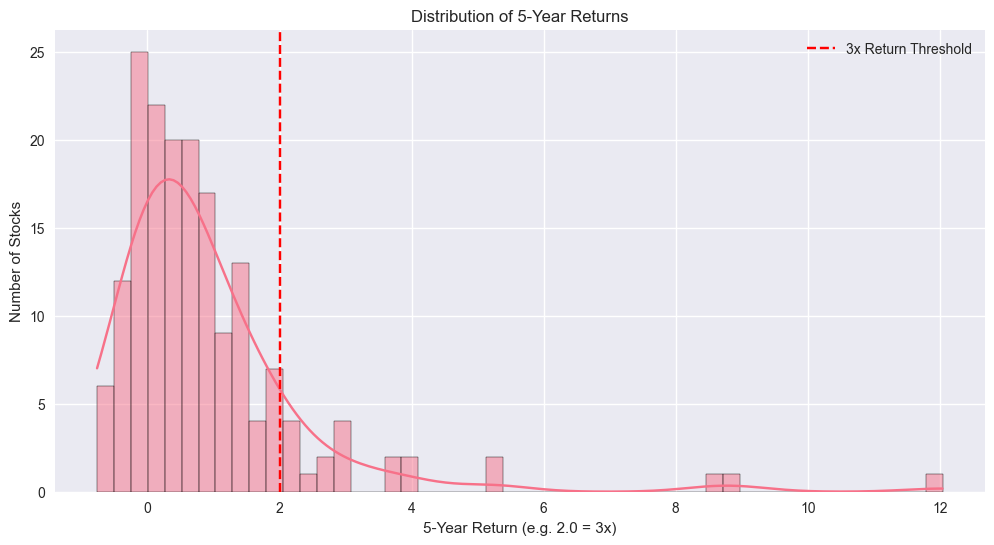


High-Growth Stocks by Sector:


,count,high_growth_rate,num_high_growth
sector,,,
Energy,12,0.416667,5
Industrials,23,0.173913,4
Technology,31,0.161290,5
Communication Services,8,0.125000,1
Financial Services,24,0.125000,3
Basic Materials,10,0.100000,1
Utilities,11,0.090909,1
Healthcare,19,0.052632,1
Consumer Cyclical,19,0.000000,0


In [3]:
# CELL 3: Exploratory Data Analysis

print("Basic Statistics of 5-Year Returns")
print(returns_df['return_5y'].describe())

# Distribution of returns
plt.figure(figsize=(12,6))
sns.histplot(returns_df['return_5y'], bins=50, kde=True)
plt.title('Distribution of 5-Year Returns')
plt.xlabel('5-Year Return (e.g. 2.0 = 3x)')
plt.ylabel('Number of Stocks')
plt.axvline(x=2.0, color='red', linestyle='--', label='3x Return Threshold')
plt.legend()
plt.show()

# High-growth by sector
sector_analysis = df.groupby('sector')['high_growth'].agg(['count', 'mean', 'sum'])
sector_analysis = sector_analysis.rename(columns={'mean': 'high_growth_rate', 'sum': 'num_high_growth'})
sector_analysis = sector_analysis.sort_values('high_growth_rate', ascending=False)

print("\nHigh-Growth Stocks by Sector:")
display(sector_analysis.head(10))

In [ ]:
# CELL 4: Save Cleaned Dataset for Next Steps

# Select useful columns for modeling
final_columns = ['ticker', 'company_name', 'sector', 'industry', 'market_cap',
                 'forward_pe', 'peg_ratio', 'revenue_growth', 'earnings_growth',
                 'return_on_equity', 'debt_to_equity', 'beta', 'return_5y', 'high_growth']

final_df = df[final_columns].copy()

# Save for modeling
final_df.to_csv("data/processed/final_dataset.csv", index=False)
final_df.to_pickle("data/processed/final_dataset.pkl")

print("Cleaned dataset saved as 'data/processed/final_dataset.csv'")
print(f"Shape: {final_df.shape}")
print("\nYou are now ready for feature engineering and modeling!")